# Notebook 04: Apprentissage Semi-Supervisé

Ce notebook combine des labels faibles issus du clustering avec un petit sous-ensemble de labels experts pour simuler un entraînement semi-supervisé.

In [10]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns

DATA_DIR = Path('../data')
LABELED_DIR = DATA_DIR / 'avec_labels'
UNLABELED_DIR = DATA_DIR / 'sans_label'
PROCESSED_DIR = DATA_DIR / 'processed'
MODELS_DIR = Path('../models')
RESULTS_DIR = Path('../results')

MODELS_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', DEVICE)

Device: cpu


## 1. Chargement des données

In [12]:
# Reconstruction des métadonnées réelles
records = []

for label_name, folder in {
    'cancer': LABELED_DIR / 'cancer',
    'normal': LABELED_DIR / 'normal'
}.items():
    if folder.exists():
        for img_path in sorted(folder.glob('*.jpg')):
            records.append({
                'image_id': img_path.stem,
                'image_path': str(img_path.resolve()),
                'label': label_name,
                'source': 'avec_labels'
            })

if UNLABELED_DIR.exists():
    for img_path in sorted(UNLABELED_DIR.glob('*.jpg')):
        records.append({
            'image_id': img_path.stem,
            'image_path': str(img_path.resolve()),
            'label': 'sans_label',
            'source': 'sans_label'
        })

metadata = pd.DataFrame(records)

# Features réelles
features_path = PROCESSED_DIR / 'features_resnet50.npy'
if not features_path.exists():
    raise FileNotFoundError(f"Fichier introuvable : {features_path}")

X = np.load(features_path).astype(np.float32)

if len(X) != len(metadata):
    raise ValueError(f"Mismatch : {len(X)} features vs {len(metadata)} lignes de metadata")

# CSV du notebook 3
analysis_csv_path = RESULTS_DIR / 'mri_metadata_clusters_notebook3.csv'
if not analysis_csv_path.exists():
    raise FileNotFoundError(
        f"Fichier introuvable : {analysis_csv_path}. "
        "Exécute d'abord le notebook 3 et crée la colonne weak_label."
    )

analysis_df = pd.read_csv(analysis_csv_path)

if len(analysis_df) != len(metadata):
    raise ValueError(f"Mismatch : {len(analysis_df)} lignes analysis_df vs {len(metadata)} metadata")

# Vérifie que weak_label existe
if 'weak_label' not in analysis_df.columns:
    raise ValueError(
        "La colonne 'weak_label' n'existe pas dans analysis_df. "
        "Crée-la à partir de ton cluster_map dans le notebook 3 puis réexporte le CSV."
    )

label_to_int = {'normal': 0, 'cancer': 1}

# Weak labels pour tout le dataset
weak_labels = analysis_df['weak_label'].map(label_to_int).to_numpy()

# Vrais labels uniquement sur les données annotées
labeled_mask = analysis_df['label'].isin(['normal', 'cancer']).to_numpy()
labeled_indices = np.where(labeled_mask)[0]
true_labels_labeled = analysis_df.loc[labeled_mask, 'label'].map(label_to_int).to_numpy()

print('X shape:', X.shape)
print('weak_labels shape:', weak_labels.shape)
print("Nombre d'images labellisées :", len(labeled_indices))
print("Répartition weak labels :")
print(pd.Series(weak_labels).value_counts().sort_index())

X shape: (1506, 2048)
weak_labels shape: (1506,)
Nombre d'images labellisées : 100
Répartition weak labels :
0    658
1    848
Name: count, dtype: int64


## 2. Split et labels experts

In [13]:
# Split uniquement sur les données labellisées pour une vraie évaluation
labeled_train_idx, labeled_temp_idx = train_test_split(
    labeled_indices,
    test_size=0.30,
    random_state=42,
    stratify=true_labels_labeled
)

temp_true = analysis_df.loc[labeled_temp_idx, 'label'].map(label_to_int).to_numpy()

labeled_val_idx, labeled_test_idx = train_test_split(
    labeled_temp_idx,
    test_size=0.50,
    random_state=42,
    stratify=temp_true
)

# Données non labellisées : utilisées seulement en entraînement avec weak labels
unlabeled_indices = np.where(~labeled_mask)[0]

# Ensemble d'entraînement final :
# - toutes les données non labellisées
# - + la partie train des données labellisées
train_idx = np.concatenate([unlabeled_indices, labeled_train_idx])

# Pour le train :
# - les non labellisées gardent weak_labels
# - les labellisées train prennent leurs vrais labels experts
train_labels = weak_labels.copy()
train_labels[labeled_train_idx] = analysis_df.loc[labeled_train_idx, 'label'].map(label_to_int).to_numpy()

# Pour validation et test : uniquement vrais labels
val_labels = analysis_df.loc[labeled_val_idx, 'label'].map(label_to_int).to_numpy()
test_labels = analysis_df.loc[labeled_test_idx, 'label'].map(label_to_int).to_numpy()

print('Train total           :', len(train_idx))
print('  dont unlabeled      :', len(unlabeled_indices))
print('  dont labeled expert :', len(labeled_train_idx))
print('Val (labeled only)    :', len(labeled_val_idx))
print('Test (labeled only)   :', len(labeled_test_idx))
print('Expert ratio dans train :', len(labeled_train_idx) / len(train_idx))

Train total           : 1476
  dont unlabeled      : 1406
  dont labeled expert : 70
Val (labeled only)    : 15
Test (labeled only)   : 15
Expert ratio dans train : 0.04742547425474255


## 3. DataLoaders

In [14]:
def make_loader(indices, labels, batch_size=32, shuffle=True):
    x_tensor = torch.tensor(X[indices], dtype=torch.float32)
    y_tensor = torch.tensor(labels, dtype=torch.long)
    ds = TensorDataset(x_tensor, y_tensor)
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle)

train_loader = make_loader(train_idx, train_labels[train_idx], batch_size=32, shuffle=True)
val_loader = make_loader(labeled_val_idx, val_labels, batch_size=32, shuffle=False)
test_loader = make_loader(labeled_test_idx, test_labels, batch_size=32, shuffle=False)

print('✅ DataLoaders prêts')

✅ DataLoaders prêts


## 4. Modèle

In [20]:
class SimpleSemiSupervisedNet(nn.Module):
    def __init__(self, input_dim=2048, n_classes=2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, n_classes)
        )

    def forward(self, x):
        return self.net(x)

n_features = X.shape[1]

model = SimpleSemiSupervisedNet(input_dim=n_features).to(DEVICE)

train_expert_labels = train_labels[labeled_train_idx]
class_counts = np.bincount(train_expert_labels, minlength=2)
class_weights = class_counts.sum() / (2 * class_counts)
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32).to(DEVICE)

criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
print("Class weights:", class_weights)

optimizer = optim.Adam(model.parameters(), lr=1e-3)

print(model)

Class weights: [1. 1.]
SimpleSemiSupervisedNet(
  (net): Sequential(
    (0): Linear(in_features=2048, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=256, out_features=64, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=64, out_features=2, bias=True)
  )
)


## 5. Entraînement

In [21]:
def run_epoch(loader, train=True):
    if train:
        model.train()
    else:
        model.eval()

    total_loss = 0.0
    y_true = []
    y_pred = []

    for xb, yb in loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)

        if train:
            optimizer.zero_grad()

        with torch.set_grad_enabled(train):
            logits = model(xb)
            loss = criterion(logits, yb)

            if train:
                loss.backward()
                optimizer.step()

        total_loss += loss.item() * len(xb)
        preds = torch.argmax(logits, dim=1)

        y_true.extend(yb.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

    avg_loss = total_loss / len(y_true)
    acc = accuracy_score(y_true, y_pred)

    return avg_loss, acc

history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

best_val_acc = -1.0
best_model_path = MODELS_DIR / 'best_semi_supervised_model.pth'

n_epochs = 8

for epoch in range(n_epochs):
    train_loss, train_acc = run_epoch(train_loader, train=True)
    val_loss, val_acc = run_epoch(val_loader, train=False)

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), best_model_path)

    print(
        f"Epoch {epoch+1}/{n_epochs} - "
        f"train_loss={train_loss:.4f} - train_acc={train_acc:.3f} - "
        f"val_loss={val_loss:.4f} - val_acc={val_acc:.3f}"
    )

print('Best val_acc:', best_val_acc)
print('Best model saved to:', best_model_path)

Epoch 1/8 - train_loss=0.2005 - train_acc=0.919 - val_loss=0.1436 - val_acc=0.867
Epoch 2/8 - train_loss=0.0942 - train_acc=0.976 - val_loss=0.2160 - val_acc=0.933
Epoch 3/8 - train_loss=0.0647 - train_acc=0.982 - val_loss=0.2304 - val_acc=0.933
Epoch 4/8 - train_loss=0.0542 - train_acc=0.984 - val_loss=0.3713 - val_acc=0.933
Epoch 5/8 - train_loss=0.0475 - train_acc=0.986 - val_loss=0.1707 - val_acc=0.933
Epoch 6/8 - train_loss=0.0476 - train_acc=0.986 - val_loss=0.6475 - val_acc=0.867
Epoch 7/8 - train_loss=0.0300 - train_acc=0.991 - val_loss=0.3444 - val_acc=0.933
Epoch 8/8 - train_loss=0.0267 - train_acc=0.993 - val_loss=0.3733 - val_acc=0.933
Best val_acc: 0.9333333333333333
Best model saved to: ../models/best_semi_supervised_model.pth


## 6. Évaluation finale

In [22]:
# Recharge le meilleur modèle
model.load_state_dict(torch.load(best_model_path, map_location=DEVICE))

test_loss, test_acc = run_epoch(test_loader, train=False)
print('Test accuracy:', test_acc)

# Baseline majoritaire sur le test set
majority_class = np.bincount(test_labels).argmax()
baseline_accuracy = float((test_labels == majority_class).mean())

improvement = float(test_acc - baseline_accuracy)

print('Baseline accuracy (classe majoritaire):', baseline_accuracy)
print('Improvement vs baseline:', improvement)

Test accuracy: 0.8
Baseline accuracy (classe majoritaire): 0.5333333333333333
Improvement vs baseline: 0.2666666666666667


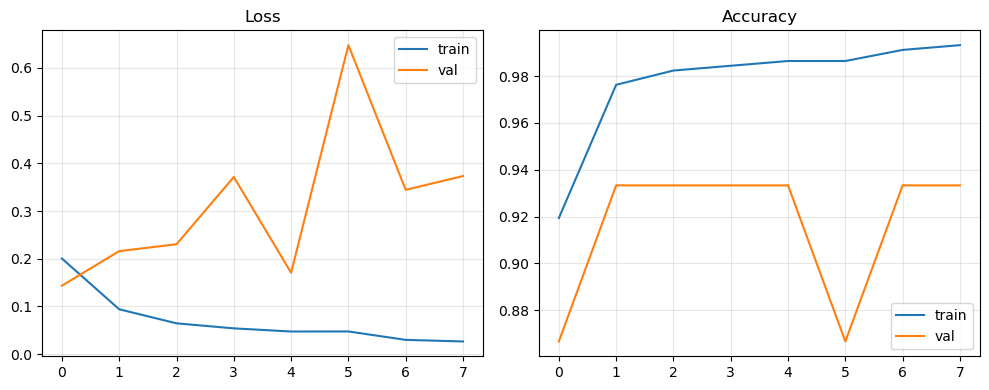

              precision    recall  f1-score   support

      normal       0.73      1.00      0.84         8
      cancer       1.00      0.57      0.73         7

    accuracy                           0.80        15
   macro avg       0.86      0.79      0.78        15
weighted avg       0.85      0.80      0.79        15



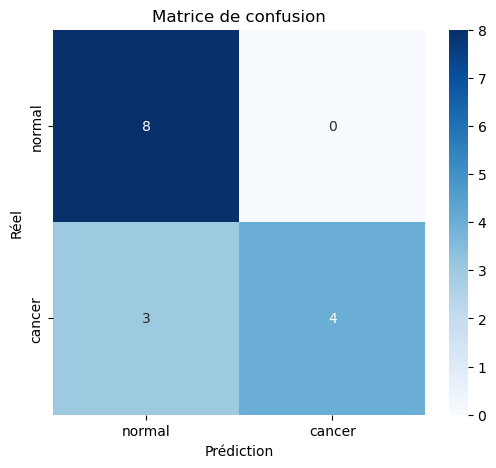

In [23]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='train')
plt.plot(history['val_loss'], label='val')
plt.title('Loss')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(history['train_acc'], label='train')
plt.plot(history['val_acc'], label='val')
plt.title('Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Prédictions test détaillées
model.eval()
all_preds = []
all_true = []

with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(DEVICE)
        logits = model(xb)
        preds = torch.argmax(logits, dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_true.extend(yb.numpy())

print(classification_report(all_true, all_preds, target_names=['normal', 'cancer']))

cm = confusion_matrix(all_true, all_preds)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['normal', 'cancer'],
            yticklabels=['normal', 'cancer'])
plt.title('Matrice de confusion')
plt.xlabel('Prédiction')
plt.ylabel('Réel')
plt.show()

## 7. Sauvegarde des résultats

In [24]:
semi_supervised_results = {
    'semi_accuracy': float(test_acc),
    'baseline_accuracy': float(baseline_accuracy),
    'improvement': float(improvement),
    'train_size': int(len(train_idx)),
    'val_size': int(len(labeled_val_idx)),
    'test_size': int(len(labeled_test_idx)),
    'expert_labeled_train_size': int(len(labeled_train_idx)),
    'unlabeled_train_size': int(len(unlabeled_indices)),
    'expert_ratio_in_train': float(len(labeled_train_idx) / len(train_idx)),
    'model_info': {
        'type': 'SimpleSemiSupervisedNet',
        'input_dim': int(n_features),
        'n_classes': 2
    }
}

results_path = RESULTS_DIR / 'semi_supervised_results.json'
with open(results_path, 'w', encoding='utf-8') as f:
    json.dump(semi_supervised_results, f, indent=2, ensure_ascii=False)

print('Résultats sauvegardés dans:', results_path)
print('Modèle sauvegardé dans:', best_model_path)

Résultats sauvegardés dans: ../results/semi_supervised_results.json
Modèle sauvegardé dans: ../models/best_semi_supervised_model.pth
